<a href="https://colab.research.google.com/github/Martin-1431/Seth_INFO4670_Fall2026/blob/main/INFO4670_Assignment_SMS_Spam_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [ ]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')


Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
> In this context, a **False Negative** is usually more costly because harmful spam reaches the user. A concrete consequence is that a phishing SMS can trick a user into clicking a fake banking link and losing money or account access. A **False Positive** is still costly: an important legitimate message (for example, a medical appointment reminder or security verification code) may be blocked and cause missed appointments or account lockouts.

**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
> My primary metric is **Recall** for the spam class, because recall directly measures how many actual spam messages are caught. Since I identified False Negatives as the most costly error, maximizing recall reduces the number of dangerous spam messages that slip through.

**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
> A dummy model that always predicts ham would get about **87% accuracy** (roughly $1 - 0.13 = 0.87$). This is misleading because the model has **0% recall for spam**: it completely fails the real objective of catching spam, even though its overall accuracy looks high.


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [ ]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)

Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%


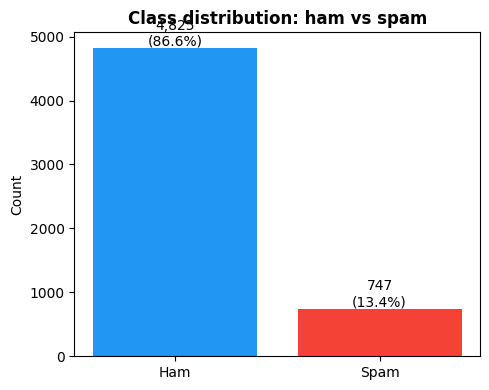

In [ ]:
# Write your code here
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1-spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

# Prove the accuracy trap with a dummy model
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)
print(f'Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [ ]:
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()

print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()


=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my b

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


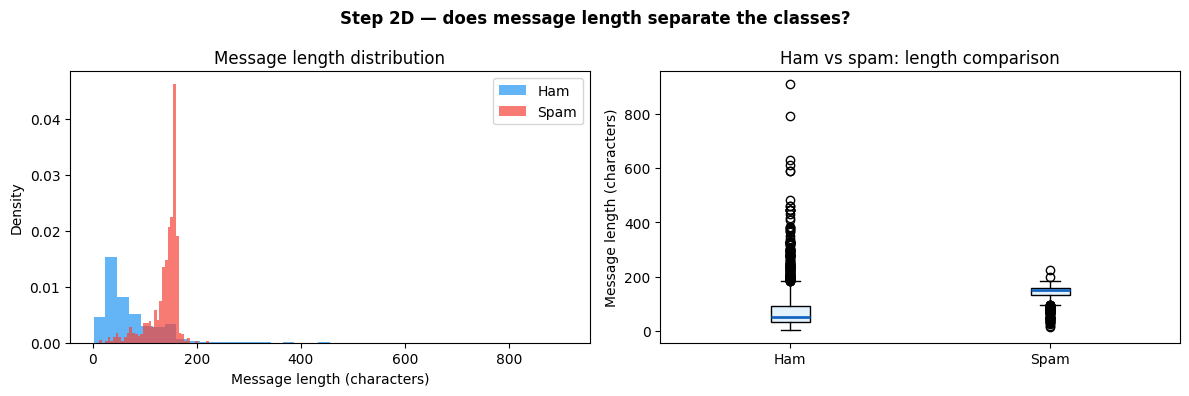

In [ ]:
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [ ]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [ ]:
# Write your code here

def build_features_v2(df):
    d = build_features(df)   # keeps all 4 starter features
    msg = d['message'].str.lower()

    # Feature 5: messages that push immediate user response
    d['has_call_to_action'] = msg.str.contains(r'\b(txt|text|reply|call|claim|stop)\b', regex=True).astype(int)

    # Feature 6: messages containing URLs/web links
    d['has_url'] = msg.str.contains(r'(https?://|www\.|\b[a-z0-9-]+\.(com|net|org|co\.uk)\b)', regex=True).astype(int)

    return d

df = build_features_v2(raw)

# Collect all feature column names — DO NOT delete this line
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)
for feat in feature_cols:
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            34.9%    6.4%  +28.5%
is_long                76.8%   14.2%  +62.7%
has_call_to_action     81.4%    7.6%  +73.7%
has_url                18.5%    0.3%  +18.2%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


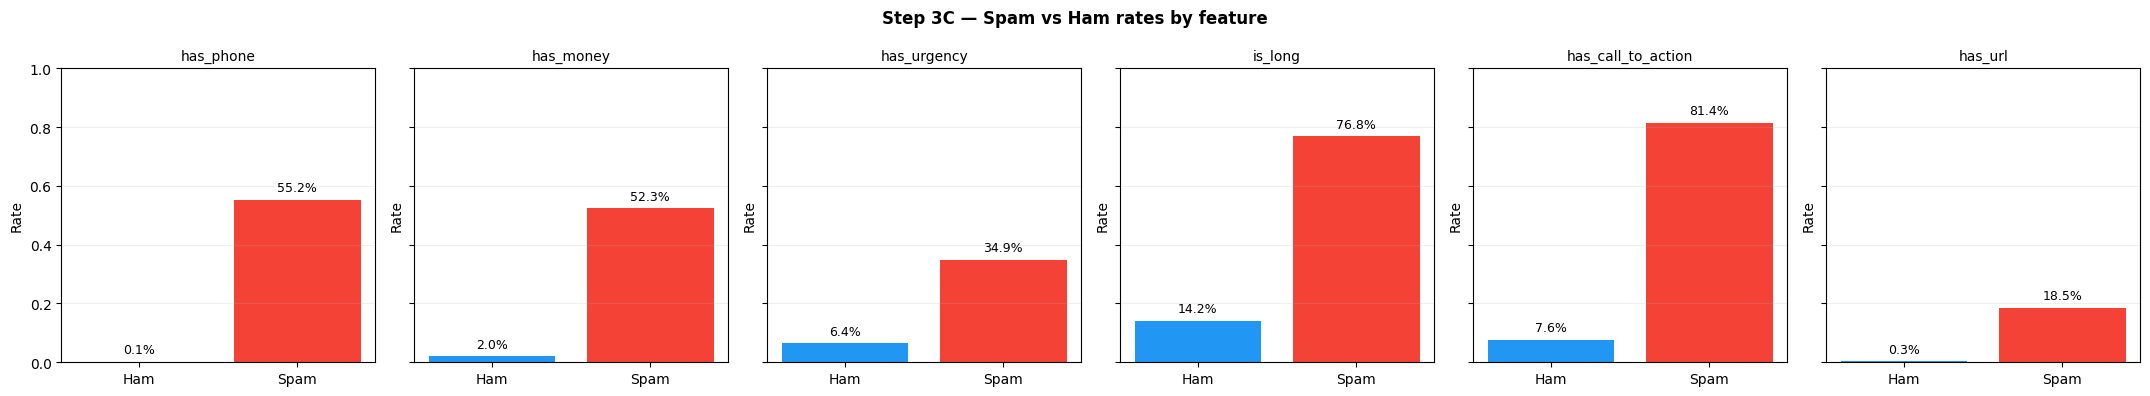

In [ ]:
# Write your code here
n_features = len(feature_cols)
fig, axes = plt.subplots(1, n_features, figsize=(3.6*n_features, 4), sharey=True)

if n_features == 1:
    axes = [axes]

for ax, feat in zip(axes, feature_cols):
    spam_rate = df[df['spam'] == 1][feat].mean()
    ham_rate = df[df['spam'] == 0][feat].mean()

    ax.bar(['Ham', 'Spam'], [ham_rate, spam_rate], color=['#2196F3', '#F44336'])
    ax.set_title(feat, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Rate')
    ax.grid(axis='y', alpha=0.2)

    for i, v in enumerate([ham_rate, spam_rate]):
        ax.text(i, v + 0.03, f'{v:.1%}', ha='center', fontsize=9)

plt.suptitle('Step 3C — Spam vs Ham rates by feature', fontweight='bold')
plt.tight_layout()
plt.show()


### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 — name and explanation:*
> **`has_call_to_action`** detects action words like `txt`, `text`, `reply`, `call`, `claim`, and `stop`. It captures messages that push immediate behavior, which is common in spam campaigns trying to trigger quick user response.

*Feature 2 — name and explanation:*
> **`has_url`** detects web links such as `http://`, `https://`, `www.`, or common domain endings like `.com`. Many spam messages include links for phishing, fake offers, or malware delivery, so link presence is a strong signal.

**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
> In my results, **`has_call_to_action`** has the largest gap: about **81.4% (spam)** vs **7.6% (ham)**, a **+73.7%** difference. A larger spam-vs-ham gap means stronger class separation, so splitting on that feature reduces impurity more and yields higher **Information Gain**. Because a Decision Tree greedily chooses the highest-gain split, a large-gap feature is very likely to appear at or near the root.

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
> A realistic failure case is a polished phishing text like: *"A sign-in request was detected on your account. Review activity in your app if this was not you."* This message can evade `has_money`, `has_urgency`, `has_phone`, and `has_call_to_action` if no explicit trigger words are used, and it may also evade `has_url` if no visible link appears in the text. That would create a possible False Negative.


---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [ ]:
# Write your code here
X = df[feature_cols].values
y = df['spam'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('Split sizes:')
print(f'  X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'  X_test : {X_test.shape}, y_test : {y_test.shape}')
print()
print('Spam rate check (stratification):')
print(f'  Overall   : {y.mean():.2%}')
print(f'  Train set : {y_train.mean():.2%}')
print(f'  Test set  : {y_test.mean():.2%}')


Split sizes:
  X_train: (4179, 6), y_train: (4179,)
  X_test : (1393, 6), y_test : (1393,)

Spam rate check (stratification):
  Overall   : 13.41%
  Train set : 13.40%
  Test set  : 13.42%


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
> `stratify=y` keeps the spam/ham proportion nearly the same in train and test sets. On an imbalanced dataset, skipping stratification can create an unrepresentative split (for example, too few spam cases in test), which makes evaluation unstable and can overestimate model quality.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
> I would prefer cross-validation when the dataset is small or class imbalance is significant and a single split may be noisy. Cross-validation averages performance across multiple folds, giving a more reliable estimate of how the model generalizes.


---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Decision Tree leaves: 15


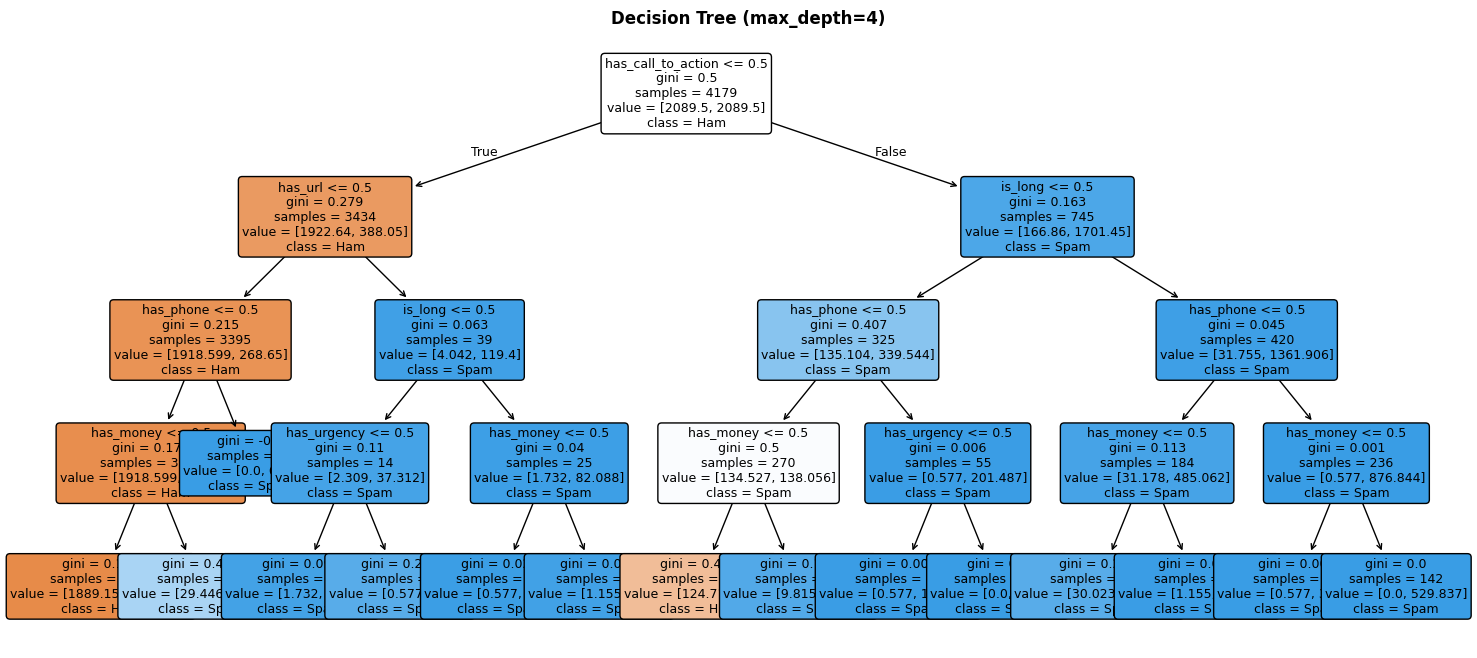

Decision Tree rules:
|--- has_call_to_action <= 0.50
|   |--- has_url <= 0.50
|   |   |--- has_phone <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_phone >  0.50
|   |   |   |--- class: 1
|   |--- has_url >  0.50
|   |   |--- is_long <= 0.50
|   |   |   |--- has_urgency <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_urgency >  0.50
|   |   |   |   |--- class: 1
|   |   |--- is_long >  0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|--- has_call_to_action >  0.50
|   |--- is_long <= 0.50
|   |   |--- has_phone <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_phone >  0.50
|   |   |   |--- has_urgency <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_urgency >  0.50
|   

In [ ]:
# Write your code here
dt = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

print(f'Decision Tree leaves: {dt.get_n_leaves()}')

plt.figure(figsize=(18, 8))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=['Ham', 'Spam'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree (max_depth=4)', fontweight='bold')
plt.show()

print('Decision Tree rules:')
print(export_text(dt, feature_names=list(feature_cols)))


### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


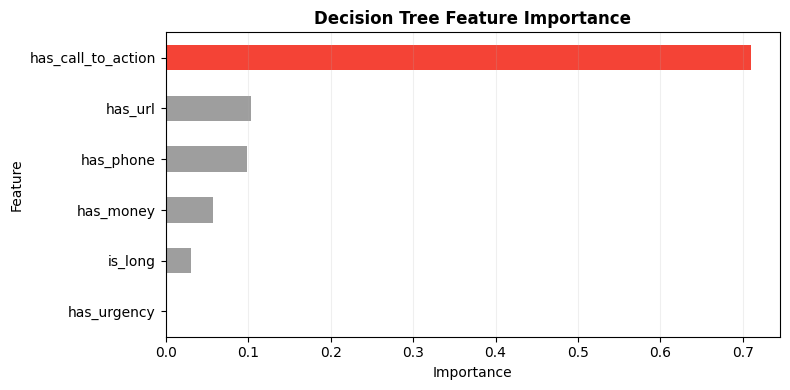

Root-driving feature (highest importance): has_call_to_action


In [ ]:
# Write your code here
importances = pd.Series(dt.feature_importances_, index=feature_cols).sort_values()

top_feature = importances.idxmax()
colors = ['#9E9E9E'] * len(importances)
colors[list(importances.index).index(top_feature)] = '#F44336'

ax = importances.plot(kind='barh', figsize=(8, 4), color=colors)
ax.set_title('Decision Tree Feature Importance', fontweight='bold')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

print(f'Root-driving feature (highest importance): {top_feature}')


### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


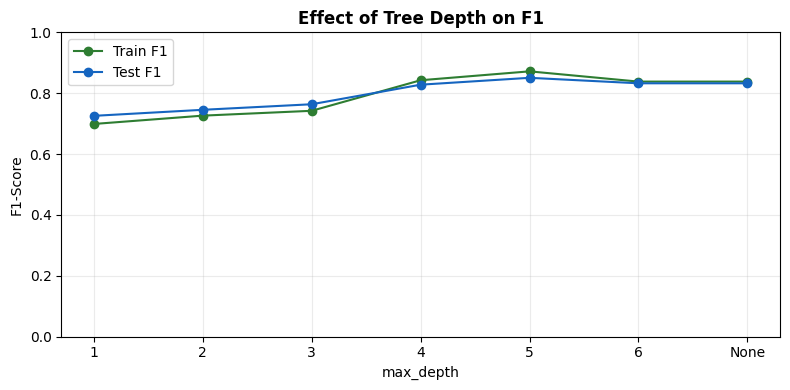

  depth  train_f1  test_f1     gap
0     1    0.6989   0.7255 -0.0267
1     2    0.7262   0.7454 -0.0192
2     3    0.7421   0.7636 -0.0215
3     4    0.8425   0.8279  0.0146
4     5    0.8718   0.8505  0.0212
5     6    0.8381   0.8325  0.0056
6  None    0.8381   0.8325  0.0056


In [ ]:
# Write your code here
depths = [1, 2, 3, 4, 5, 6, None]
train_f1, test_f1 = [], []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)

    y_tr_pred = model.predict(X_train)
    y_te_pred = model.predict(X_test)

    train_f1.append(f1_score(y_train, y_tr_pred, zero_division=0))
    test_f1.append(f1_score(y_test, y_te_pred, zero_division=0))

depth_labels = [str(d) if d is not None else 'None' for d in depths]
plt.figure(figsize=(8, 4))
plt.plot(depth_labels, train_f1, marker='o', label='Train F1', color='#2E7D32')
plt.plot(depth_labels, test_f1, marker='o', label='Test F1', color='#1565C0')
plt.title('Effect of Tree Depth on F1', fontweight='bold')
plt.xlabel('max_depth')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

depth_table = pd.DataFrame({
    'depth': depth_labels,
    'train_f1': np.round(train_f1, 4),
    'test_f1': np.round(test_f1, 4),
    'gap': np.round(np.array(train_f1) - np.array(test_f1), 4)
})
print(depth_table)


### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [ ]:
# Write your code here
nb = BernoulliNB()
nb.fit(X_train, y_train)
print('Bernoulli Naive Bayes trained successfully.')


Bernoulli Naive Bayes trained successfully.


---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


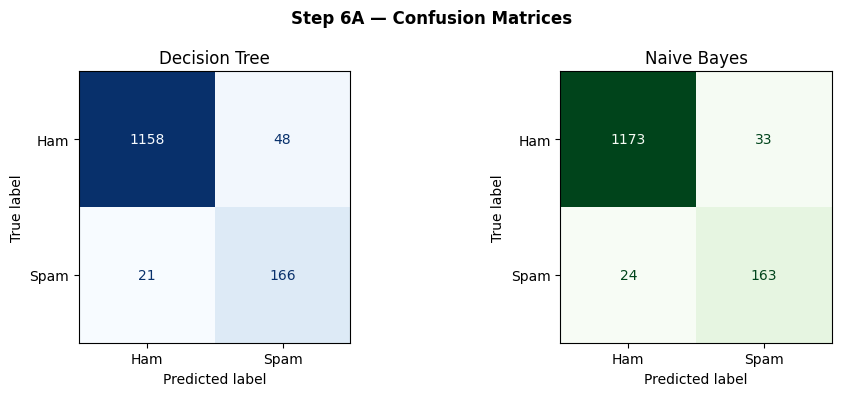

Decision Tree:
  TP=166, FP=48, FN=21, TN=1158
Naive Bayes:
  TP=163, FP=33, FN=24, TN=1173


In [ ]:
# Write your code here
y_pred_dt = dt.predict(X_test)
y_pred_nb = nb.predict(X_test)

cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_nb = confusion_matrix(y_test, y_pred_nb)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm_dt, display_labels=['Ham', 'Spam']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Decision Tree')
ConfusionMatrixDisplay(cm_nb, display_labels=['Ham', 'Spam']).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Naive Bayes')
plt.suptitle('Step 6A — Confusion Matrices', fontweight='bold')
plt.tight_layout()
plt.show()

def print_cm_breakdown(name, cm):
    tn, fp, fn, tp = cm.ravel()
    print(f'{name}:')
    print(f'  TP={tp}, FP={fp}, FN={fn}, TN={tn}')

print_cm_breakdown('Decision Tree', cm_dt)
print_cm_breakdown('Naive Bayes', cm_nb)


### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


           Model  Accuracy  Precision  Recall  F1-Score
0  Decision Tree    0.9505     0.7757  0.8877    0.8279
1    Naive Bayes    0.9591     0.8316  0.8717    0.8512


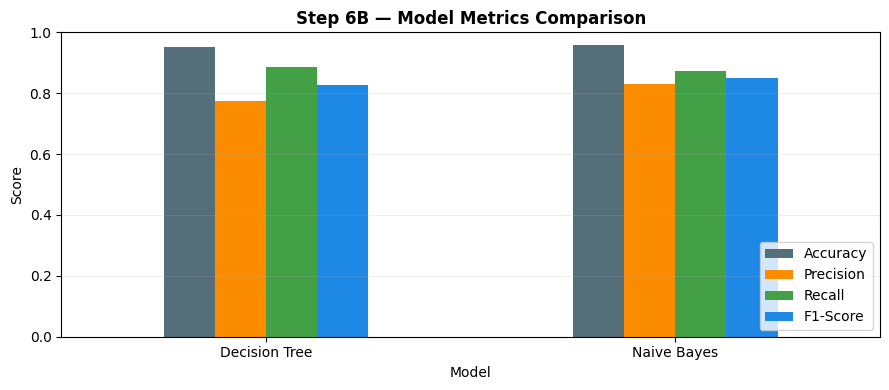

In [ ]:
# Write your code here
metrics_df = pd.DataFrame([
    {
        'Model': 'Decision Tree',
        'Accuracy': accuracy_score(y_test, y_pred_dt),
        'Precision': precision_score(y_test, y_pred_dt, zero_division=0),
        'Recall': recall_score(y_test, y_pred_dt, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred_dt, zero_division=0),
    },
    {
        'Model': 'Naive Bayes',
        'Accuracy': accuracy_score(y_test, y_pred_nb),
        'Precision': precision_score(y_test, y_pred_nb, zero_division=0),
        'Recall': recall_score(y_test, y_pred_nb, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred_nb, zero_division=0),
    }
])

print(metrics_df.round(4))

plot_df = metrics_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
ax = plot_df.plot(kind='bar', figsize=(9, 4), ylim=(0, 1), color=['#546E7A', '#FB8C00', '#43A047', '#1E88E5'])
ax.set_title('Step 6B — Model Metrics Comparison', fontweight='bold')
ax.set_ylabel('Score')
ax.grid(axis='y', alpha=0.2)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [ ]:
# Write your code here
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_cv_model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
nb_cv_model = BernoulliNB()

dt_f1_cv = cross_val_score(dt_cv_model, X, y, cv=cv, scoring='f1')
nb_f1_cv = cross_val_score(nb_cv_model, X, y, cv=cv, scoring='f1')

print('5-fold Cross-Validation F1 scores:')
print(f'  Decision Tree: mean={dt_f1_cv.mean():.4f}, std={dt_f1_cv.std():.4f}, folds={np.round(dt_f1_cv, 4)}')
print(f'  Naive Bayes  : mean={nb_f1_cv.mean():.4f}, std={nb_f1_cv.std():.4f}, folds={np.round(nb_f1_cv, 4)}')


5-fold Cross-Validation F1 scores:
  Decision Tree: mean=0.8492, std=0.0228, folds=[0.8638 0.8381 0.8795 0.8127 0.8517]
  Naive Bayes  : mean=0.8620, std=0.0128, folds=[0.8766 0.8479 0.875  0.8467 0.8636]


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
> TP = **166**, FN = **21**, FP = **48**.

*Naive Bayes:*
> TP = **163**, FN = **24**, FP = **33**.

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
> I chose **Recall** in Step 1. On test data, **Decision Tree** has higher recall (**0.8877**) than Naive Bayes (**0.8717**), so it wins by **0.0160** (1.60 percentage points). The cross-validation in Step 6C used **F1**, not recall, and there Naive Bayes has a slightly higher mean F1 (**0.8620 vs 0.8492**), so it does **not fully confirm** the recall-based winner.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

*Your memo:*
> I recommend the **Decision Tree** for deployment if our top business priority is catching as much spam as possible. It achieved the highest spam recall on the test set (**0.8877**), which means fewer dangerous spam messages reach users. Its key weakness is a higher false-positive count (**48** vs **33** for Naive Bayes), so more legitimate messages may be blocked. A practical improvement is to tune the decision threshold or apply cost-sensitive post-processing to reduce false positives while preserving high recall. We should also retrain periodically with newer data because spam language evolves quickly.

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
> Two features likely to weaken on modern spam are **`has_money`** and **`has_urgency`**. Modern phishing texts often avoid obvious words like "free," "winner," or "urgent" and instead use calm, professional wording to appear trustworthy. As a result, these keyword-based features can miss sophisticated spam and produce more False Negatives.
